In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data (not raw!)
df = pd.read_csv("1_Data_Exploration_Cleaning .csv")
print(df.shape)
df.head()

(9988, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print((df["Balance"] == 0).sum())  # how many zeros?

3611


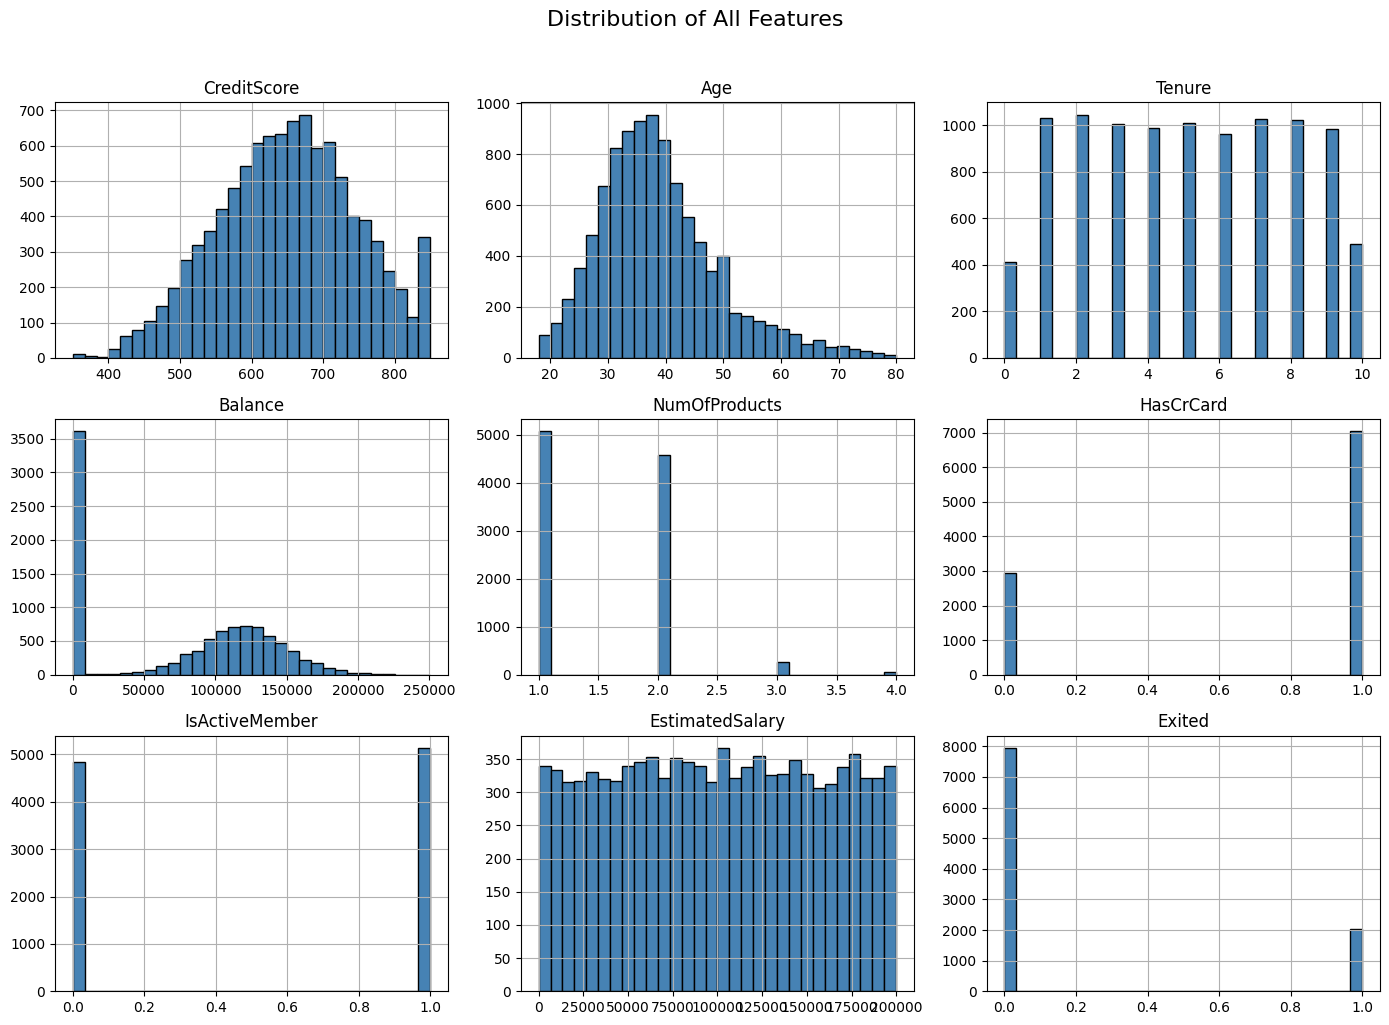

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# See overall distributions of all columns at once
df.hist(bins=30, figsize=(14, 10), color="steelblue", edgecolor="black")
plt.suptitle("Distribution of All Features", y=1.02, fontsize=16)
plt.savefig("salary_distribution.png", dpi=300, bbox_inches='tight') 

plt.tight_layout()
plt.show()

In [19]:
# 1. Balance zero investigation
print(f"Zero balance customers: {(df['Balance'] == 0).sum()}")
print(f"% who churned with 0 balance: {df[df['Balance']==0]['Exited'].mean()*100:.1f}%")
print(f"% who churned with balance: {df[df['Balance']>0]['Exited'].mean()*100:.1f}%")

# 2. NumOfProducts churn rate
print(df.groupby("NumOfProducts")["Exited"].mean() * 100)

Zero balance customers: 3611
% who churned with 0 balance: 13.8%
% who churned with balance: 24.1%
NumOfProducts
1     27.721993
2      7.593280
3     82.706767
4    100.000000
Name: Exited, dtype: float64


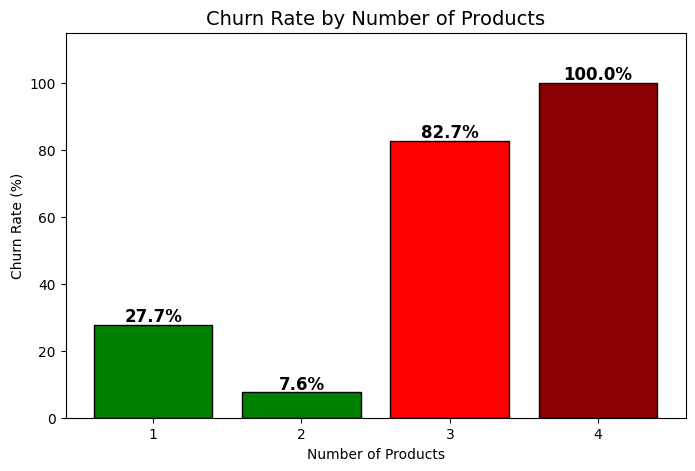

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn rate by number of products
churn_by_products = df.groupby("NumOfProducts")["Exited"].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(churn_by_products.index, 
               churn_by_products.values,
               color=["green", "green", "red", "darkred"],
               edgecolor="black")

# Add percentage labels on each bar
for bar, val in zip(bars, churn_by_products.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1,
             f"{val:.1f}%", 
             ha="center", fontsize=12, fontweight="bold")

plt.title("Churn Rate by Number of Products", fontsize=14)
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks([1, 2, 3, 4])
plt.ylim(0, 115)
plt.show()

In [22]:
#"More products ≠ more loyalty after a point" The bank should focus on getting customers to 2 products — that's the loyalty sweet spot. 
#Pushing 3-4 products is actually driving customers away.

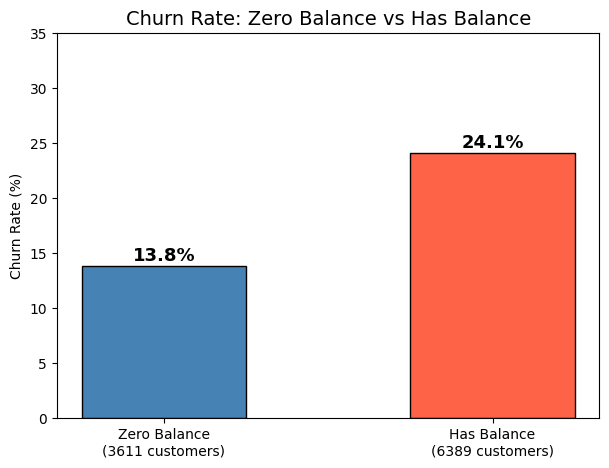

In [24]:
plt.figure(figsize=(7, 5))
bars = plt.bar(["Zero Balance\n(3611 customers)", 
                "Has Balance\n(6389 customers)"],
               [13.8, 24.1],
               color=["steelblue", "tomato"],
               edgecolor="black",
               width=0.5)

# Add labels
for bar, val in zip(bars, [13.8, 24.1]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{val}%",
             ha="center", fontsize=13, fontweight="bold")

plt.title("Churn Rate: Zero Balance vs Has Balance", fontsize=14)
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 35)
plt.show()

In [25]:
# Create age groups first
df["AgeGroup"] = pd.cut(df["Age"], 
                         bins=[0, 30, 40, 50, 60, 100],
                         labels=["<30", "30-40", "40-50", "50-60", "60+"])

# Churn rate by age group
print(df.groupby("AgeGroup")["Exited"].mean() * 100)

AgeGroup
<30       7.520325
30-40    12.087171
40-50    33.965517
50-60    56.210790
60+      25.221239
Name: Exited, dtype: float64


In [26]:
# Churn rate by Age Group AND Gender
age_gender = df.groupby(["AgeGroup", "Gender"])["Exited"].mean() * 100
print(age_gender)

AgeGroup  Gender
<30       Female     9.886364
          Male       5.606618
30-40     Female    15.569168
          Male       9.349920
40-50     Female    38.909091
          Male      29.508197
50-60     Female    65.217391
          Male      47.536946
60+       Female    30.288462
          Male      20.901639
Name: Exited, dtype: float64


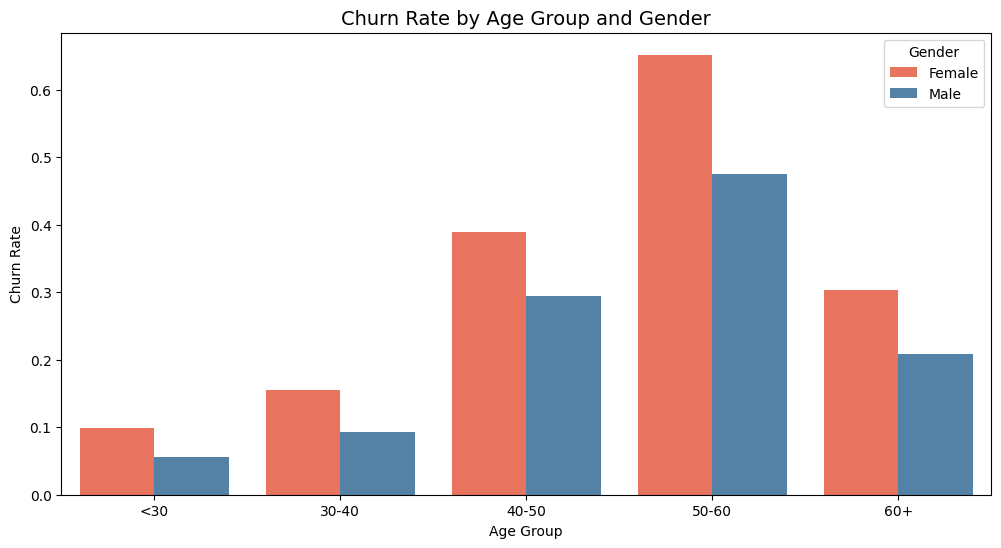

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df, 
            x="AgeGroup", 
            y="Exited", 
            hue="Gender",
            palette={"Male": "steelblue", "Female": "tomato"},
            errorbar=None)

plt.title("Churn Rate by Age Group and Gender", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Churn Rate")
plt.legend(title="Gender")
plt.show()

In [28]:
print(df.groupby("Gender")["Exited"].mean() * 100)

Gender
Female    25.077126
Male      16.477064
Name: Exited, dtype: float64


In [29]:
# 1. Geography vs Churn
print(df.groupby("Geography")["Exited"].mean() * 100)

# 2. Active Member vs Churn
print(df.groupby("IsActiveMember")["Exited"].mean() * 100)

Geography
France     16.160607
Germany    32.482043
Spain      16.680129
Name: Exited, dtype: float64
IsActiveMember
0    26.835809
1    14.299611
Name: Exited, dtype: float64


In [30]:
# Save the dataframe with AgeGroup column we created
df.to_csv("churn_cleaned.csv", index=False)
print("EDA Complete! File saved.")

EDA Complete! File saved.


In [33]:
# Save cleaned dataframe as CSV
df.to_csv("02_EDA .csv", index=False)
print("Saved successfully!")


Saved successfully!
